# Matplotlib

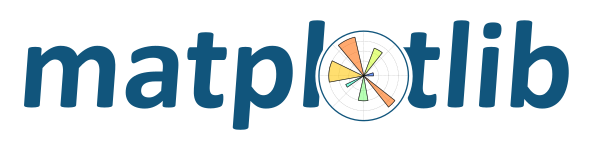

**Autores:** Moisés Velasco Lozano &nbsp;&middot;&nbsp; Josué Heber Fabián Martínez


## Introducción


Matplotlib es una biblioteca de Python utilizada para la creación de gráficos y visualizaciones de datos. Permite generar gráficos de alta calidad de manera sencilla, ayudando a representar información de forma visual para facilitar su análisis e interpretación.

Entre sus principales características se encuentran:

* Creación de gráficos de líneas, barras, histogramas, dispersión y sectores.
* Personalización de colores, títulos, etiquetas y estilos.
* Generación de múltiples gráficos en una misma figura.
* Exportación de gráficos en diferentes formatos (PNG, PDF, SVG, entre otros).

https://matplotlib.org/stable/index.html

https://htmlcolorcodes.com/color-names/

https://matplotlib.org/stable/users/explain/colors/colormaps.html

**Nota:** los enlaces incluidos a lo largo del notebook (documentación oficial de Matplotlib, catálogos de colores, mapas de color, etc.) son solo material de consulta para quien lea el notebook — no es necesario abrirlos para poder ejecutar o entender el código.


<table width="100%">
<tr>
<td bgcolor="#E3F2FD">

# <font color="blue">**1. Generar un DataFrame para los graficos**</font>

</td>
</tr>
</table>

**¿Qué hace este código?**

Importa las librerías que se usarán en todo el notebook: `pandas` para tablas de datos, `random` para generar números aleatorios, `matplotlib` (y su módulo `pyplot`) para graficar, y `numpy` para cálculo numérico.

In [ ]:
import pandas as pd
import random as rd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np


**Nota**
Inmportamos la librerías necesarias que usaremos durante todo es Notebook.



*   Importamos **pandas** para el manejo de datos y declaramos la variable como pd
*   Importamos **random** para generar números aleatorios y declaramos la variable como rd
*   Importamos **matplotlib** para crear las graficas y declaramos la como mpl
*   Importamos **numpy** para el manejo de formulas matemáticas y lo declaramos como np




Antes de graficar es una buena práctica organizar los datos en un `DataFrame` de Pandas: cada columna representa una variable (por ejemplo, un pozo) y el índice representa la variable independiente (tiempo, profundidad, etc.). Esto facilita enormemente graficar series múltiples, ya que Matplotlib y Pandas se integran de forma nativa (`dataframe.plot()`).

**Ejemplo aplicado:** generaremos un DataFrame con la presión de cabezal (psi) registrada durante 10 días para 4 pozos de un mismo campo.

Definimos 5 listas vacías

In [ ]:
dias = []
pozo1 = []
pozo2 = []
pozo3 = []
pozo4 = []


Hacemos un ciclo para simular lecturas diarias de presión de cabezal [psi] en 4 pozos


**¿Qué hace este código?**

Crea 5 listas vacías y, dentro de un ciclo `for`, simula 10 lecturas diarias de presión de cabezal para 4 pozos usando números aleatorios dentro de rangos realistas. Al final arma un `DataFrame` de pandas (`df_presion`) con esa información, usando el día como índice.

In [ ]:
dias = []
pozo1 = []
pozo2 = []
pozo3 = []
pozo4 = []

for i in range(0, 10):
    p1 = 1800 + rd.random() * 200
    p2 = 1500 + rd.random() * 150
    p3 = 2100 + rd.random() * 180
    p4 = 1200 + rd.random() * 100

    dias.append(i + 1)
    pozo1.append(p1)
    pozo2.append(p2)
    pozo3.append(p3)
    pozo4.append(p4)

df_presion = pd.DataFrame({'Pozo-1': pozo1, 'Pozo-2': pozo2, 'Pozo-3': pozo3, 'Pozo-4': pozo4})
df_presion.index = dias
df_presion.index.name = 'Día'


**Nota:** comentarios originales de este bloque de código:

- Definir 5 listas vacías
- Ciclo para simular lecturas diarias de presión de cabezal (psi) en 4 pozos
- Definir un DataFrame con la información de las listas

Definimos un DataFrame con la información de las listas

In [ ]:
df_presion




<table width="100%">
<tr>
<td bgcolor="#E3F2FD">

# <font color="blue">**2. Gráfico de líneas**</font>

</td>
</tr>
</table>

**Teoría**

El gráfico de líneas (`ax.plot()`) conecta puntos de datos mediante segmentos, siendo ideal para representar la evolución de una variable continua respecto a otra (típicamente el tiempo). Es uno de los gráficos más usados en ingeniería para visualizar tendencias, ciclos o comportamientos de declinación.

Parámetros más usados: `color`, `linestyle`, `linewidth`, `marker`.

**¿Qué hace este código?**

Configura el tipo de letra global de Matplotlib y luego construye una gráfica de líneas: toma los días (`x`) y la presión del Pozo-1 (`y`) del DataFrame `df_presion`, dibuja la curva con marcadores circulares, etiqueta los ejes y agrega un pie de figura debajo del gráfico.

In [ ]:
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Serif'

x = df_presion.index
y = df_presion['Pozo-1']

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(x, y, color='blue', linestyle='-', marker='o', linewidth=2)
ax.set_xlabel('Tiempo [día]', fontsize=14)
ax.set_ylabel('Presión [psi]', fontsize=14)
ax.grid(alpha=0.3)

fig.tight_layout(rect=[0, 0.06, 1, 1])
fig.text(0.5, 0.0, 'Presión de cabezal — Pozo-1', ha='center', va='bottom', fontsize=14, fontweight='bold')
plt.show()


**Nota:** comentarios originales de este bloque de código:

- Importar librería (necesario)
- Definir tipo de letra a usar (opcional)
- https://matplotlib.org/stable/users/explain/text/text_props.html#text-props
- --- Ejemplo aplicado a ingeniería petrolera ---
- Evolución de la presión de cabezal del Pozo-1 durante 10 días
- Pie de figura (caption) debajo de la gráfica

El enlace de la documentación de Matplotlib solo es una referencia opcional para consultar los estilos de texto disponibles.

<table width="100%">
<tr>
<td bgcolor="#E3F2FD">

# <font color="blue">**3. Gráfico de barras**</font>

</td>
</tr>
</table>

**Teoría**

El gráfico de barras (`kind='bar'`) representa valores discretos o categóricos mediante rectángulos cuya altura es proporcional al valor. Es ideal para comparar magnitudes entre categorías, por ejemplo la producción de distintos pozos en diferentes periodos.

* Barras **agrupadas**: comparan categorías lado a lado.
* Barras **apiladas** (`stacked=True`): muestran la composición total además de la comparación entre categorías.

**¿Qué hace este código?**

Construye un `DataFrame` (`df_produccion`) a partir de un diccionario con la producción mensual (enero, febrero, marzo) de 4 pozos, usando los nombres de los pozos como índice.

In [ ]:
series = {'Enero': [320, 210, 480, 150], 'Febrero': [300, 205, 455, 140], 'Marzo': [285, 198, 430, 132]}
pozos_idx = ['Pozo-1', 'Pozo-2', 'Pozo-3', 'Pozo-4']

df_produccion = pd.DataFrame(series, index=pozos_idx)
df_produccion


**Nota:** comentarios originales de este bloque de código:

- --- Ejemplo aplicado a ingeniería petrolera ---
- Producción promedio mensual (bbl/día) de 4 pozos durante el primer trimestre

**¿Qué hace este código?**

Define varias paletas de colores (listas de códigos hexadecimales) que se reutilizan más adelante en distintas gráficas del notebook.

In [ ]:
paleta_vibrante = ["#FF006E", "#FB5607", "#FFBE0B", "#8338EC", "#3A86FF"]
paleta_tierra = ["#7F4F24", "#A68A64", "#B6AD90", "#DDB892", "#EDE0D4" ]
paleta_naturaleza = ["#2D6A4F", "#40916C", "#52B788", "#74C69D", "#B7E4C7"]
paleta_otoño = ["#0F0E17", "#FF8906", "#F25F4C", "#E53170", "#7F5AF0" ]
paleta_tipoviridis = ["#440154", "#3B528B", "#21918C", "#FDE725"]


**Nota:** comentarios originales de este bloque de código:

- Paletas de colores

#### 3.1 Barras agrupadas

**¿Qué hace este código?**

Grafica `df_produccion` como barras agrupadas (una barra por pozo y por mes), coloreadas con la paleta tipo *viridis*, y agrega etiquetas, leyenda y pie de figura.

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))

df_produccion.plot(ax=ax, kind='bar', width=0.8, color=paleta_tipoviridis)

ax.set_ylabel('Gasto [bbl/día]', fontsize=14)
ax.legend(df_produccion.columns, loc="upper right")
ax.minorticks_on()
ax.set_ylim(0, 550)

fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.text(0.5, 0.0, 'Producción promedio por pozo (q1)', ha='center', va='bottom', fontsize=14, fontweight='bold')
plt.show()


**Nota:** comentarios originales de este bloque de código:

- Definición de figura
- Uso de dataframe para el gráfico (barras agrupadas)
- Propiedades del gráfico
- Pie de figura (caption) debajo de la gráfica

#### 3.2 Barras apiladas

**¿Qué hace este código?**

Grafica la misma información de `df_produccion`, pero como barras apiladas, para mostrar la producción trimestral acumulada de cada pozo.

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
df_produccion.plot(ax=ax, kind='bar', color=paleta_naturaleza, stacked=True)
ax.set_ylabel('Gasto [bbl/día]', fontsize=14)
ax.legend(df_produccion.columns, loc="upper right")
ax.minorticks_on()
ax.set_ylim(0, 1500)

fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.text(0.5, 0.0, 'Producción acumulada por pozo (q1)', ha='center', va='bottom', fontsize=14, fontweight='bold')
plt.show()


**Nota:** comentarios originales de este bloque de código:

- Gráfico de barras apiladas: producción trimestral acumulada por pozo
- Pie de figura (caption) debajo de la gráfica

<table width="100%">
<tr>
<td bgcolor="#E3F2FD">

# <font color="blue">**4. Histogramas**</font>

</td>
</tr>
</table>

**Teoría**

El histograma (`ax.hist()`) muestra la distribución de frecuencia de una variable continua, dividiendo el rango de valores en intervalos (`bins`) y contando cuántas observaciones caen en cada uno. Es una herramienta clave en petrofísica para analizar la distribución de propiedades como porosidad o permeabilidad a lo largo de un campo o yacimiento.

**¿Qué hace este código?**

Simula 1000 mediciones de porosidad, permeabilidad y saturación de agua de un campo petrolero usando números aleatorios uniformes, y las guarda en tres listas.

In [ ]:
poro_campo = []
perm_campo = []
sw_campo = []

for i in range(0, 1000):

    poro = rd.random() * 30
    poro_campo.append(poro)

    perm = rd.random() * 500
    perm_campo.append(perm)

    sw = rd.random() * 100
    sw_campo.append(sw)


**Nota:** comentarios originales de este bloque de código:

- --- Ejemplo aplicado a ingeniería petrolera ---
- Simulación de 1000 mediciones de porosidad y permeabilidad de un campo petrolero
- porosidad [%]
- permeabilidad [mD]
- saturación de agua [%]

#### 4.1 Histograma de porosidad de campo

**¿Qué hace este código?**

Dibuja un histograma con la distribución de porosidad simulada (`poro_campo`), dividiendo los valores en 30 intervalos (`bins`).

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.hist(poro_campo, bins=30, color='red', edgecolor='black')
ax.set_xlabel('Porosidad [%]', fontsize=14)
ax.set_ylabel('Frecuencia', fontsize=14)

fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.text(0.5, 0.0, 'Distribución de porosidad de campo', ha='center', va='bottom', fontsize=14, fontweight='bold')
plt.show()


**Nota:** comentarios originales de este bloque de código:

- Histograma de porosidad de campo
- Pie de figura (caption) debajo de la gráfica

#### 4.2 Histograma de un yacimiento (distribución normal)

**¿Qué hace este código?**

Genera 10,000 valores de porosidad siguiendo una distribución normal (media 15%, desviación 4%) para simular un yacimiento específico, y los grafica en un histograma.

In [ ]:
poro_yacimiento = np.random.normal(loc=15.0, scale=4.0, size=10000)

fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(poro_yacimiento, bins=30, color='red', edgecolor='black')
ax.set_xlabel('Porosidad [%]', fontsize=14)
ax.set_ylabel('Frecuencia', fontsize=14)

fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.text(0.5, 0.0, 'Distribución de porosidad — Yacimiento X', ha='center', va='bottom', fontsize=14, fontweight='bold')
plt.show()


**Nota:** comentarios originales de este bloque de código:

- Distribución de porosidad de un yacimiento específico (comportamiento normal)
- Pie de figura (caption) debajo de la gráfica

<table width="100%">
<tr>
<td bgcolor="#E3F2FD">

# <font color="blue">**5. Dispersión**</font>

</td>
</tr>
</table>

**Teoría**

El gráfico de dispersión (`ax.scatter()`) representa pares de valores (x, y) como puntos individuales, permitiendo observar relaciones o correlaciones entre dos variables. En petrofísica, el **crossplot de porosidad vs. permeabilidad** es uno de los gráficos más utilizados para caracterizar la calidad de una roca yacimiento. Añadiendo color (`c`) y/o tamaño (`s`) se puede incorporar una tercera o cuarta variable al mismo gráfico.

#### 5.1 Crossplot clásico (porosidad vs. permeabilidad)

**¿Qué hace este código?**

Dibuja un *crossplot* (gráfico de dispersión) clásico de petrofísica: porosidad en el eje X contra permeabilidad en el eje Y.

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(poro_campo, perm_campo, color='red', edgecolors='black')
ax.set_xlabel('Porosidad [%]', fontsize=14)
ax.set_ylabel('Permeabilidad [mD]', fontsize=14)

fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.text(0.5, 0.0, 'Crossplot Porosidad vs. Permeabilidad', ha='center', va='bottom', fontsize=14, fontweight='bold')
plt.show()


**Nota:** comentarios originales de este bloque de código:

- --- Ejemplo aplicado a ingeniería petrolera ---
- Crossplot clásico de petrofísica: porosidad vs. permeabilidad
- Pie de figura (caption) debajo de la gráfica

#### 5.2 Crossplot coloreado por una tercera variable

**¿Qué hace este código?**

Repite el crossplot de porosidad vs. permeabilidad, pero coloreando cada punto según una tercera variable (la saturación de agua) usando un mapa de color y una barra de color (`colorbar`).

In [ ]:
fig = plt.figure()
plt.scatter(poro_campo, perm_campo, c=sw_campo, cmap='viridis', s=100)
plt.colorbar(label='Saturación de agua [%]')
plt.xlabel("Porosidad [%]", fontsize=14)
plt.ylabel("Permeabilidad [mD]", fontsize=14)

fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.text(0.5, 0.0, 'Crossplot Porosidad-Permeabilidad coloreado por Sw', ha='center', va='bottom', fontsize=14, fontweight='bold')
plt.show()


**Nota:** comentarios originales de este bloque de código:

- Crossplot coloreado por saturación de agua (tercera variable)
- Pie de figura (caption) debajo de la gráfica

#### 5.3 Gráfico de burbujas

**¿Qué hace este código?**

Convierte el crossplot anterior en un gráfico de burbujas: el tamaño de cada punto también representa la saturación de agua, además del color.

In [ ]:
fig = plt.figure()
plt.scatter(poro_campo, perm_campo, c=sw_campo, cmap='viridis', s=np.array(sw_campo), alpha=0.6)
plt.colorbar(label='Saturación de agua [%]')
plt.xlabel("Porosidad [%]", fontsize=14)
plt.ylabel("Permeabilidad [mD]", fontsize=14)

fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.text(0.5, 0.0, 'Crossplot tipo burbuja (tamaño = Sw)', ha='center', va='bottom', fontsize=14, fontweight='bold')
plt.show()


**Nota:** comentarios originales de este bloque de código:

- Gráfico de burbujas: tamaño y color codifican saturación de agua
- Pie de figura (caption) debajo de la gráfica

<table width="100%">
<tr>
<td bgcolor="#E3F2FD">

# <font color="blue">**6. Gráfico de pastel**</font>

</td>
</tr>
</table>

**Teoría**

El gráfico de pastel (`ax.pie()`) representa la proporción de cada categoría respecto al total, expresada como porcentaje del círculo completo. Es útil cuando se quiere comunicar de forma simple cómo se reparte un total entre pocas categorías, por ejemplo la clasificación de reservas de un campo (probadas, probables y posibles).

**¿Qué hace este código?**

Dibuja un gráfico de pastel con la clasificación de reservas de un campo (probadas, probables, posibles), mostrando el porcentaje de cada categoría.

In [ ]:
labels = ['Reservas probadas', 'Reservas probables', 'Reservas posibles']
slices = [55, 30, 15]

fig, ax = plt.subplots(figsize=(5, 5))

ax.pie(slices, labels=labels, autopct='%1.1f%%', startangle=90,
        colors=['#1dc458', '#cceb34', '#daf097'], textprops={'fontsize': 12})

fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.text(0.5, 0.0, 'Clasificación de reservas — Campo X', ha='center', va='bottom', fontsize=14, fontweight='bold')
plt.show()


**Nota:** comentarios originales de este bloque de código:

- --- Ejemplo aplicado a ingeniería petrolera ---
- Clasificación de reservas de un campo (% del total)
- Pie de figura (caption) debajo de la gráfica

<table width="100%">
<tr>
<td bgcolor="#E3F2FD">

# <font color="blue">**7. Gráficos agrupados**</font>

</td>
</tr>
</table>

**Teoría**

`plt.subplots(filas, columnas)` permite combinar varios gráficos distintos en una sola figura, algo muy útil para construir **dashboards** que resuman varios indicadores de un pozo o campo de un solo vistazo (producción, calidad de roca, reservas, presión, etc.).

**¿Qué hace este código?**

Arma una figura con una cuadrícula de 2x2 subgráficas (un mini-dashboard) que combina cuatro gráficas ya vistas: producción de enero por pozo, el crossplot porosidad-permeabilidad, la clasificación de reservas y la presión de cabezal del Pozo-1.

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

axs[0, 0].bar(df_produccion.index, df_produccion['Enero'], color='skyblue')
axs[0, 0].set_title("Producción — Enero")
axs[0, 0].set_xlabel("Pozo")
axs[0, 0].set_ylabel("Gasto [bbl/día]")

axs[0, 1].scatter(poro_campo, perm_campo, color='red', alpha=0.5)
axs[0, 1].set_title("Crossplot Poro-Perm")
axs[0, 1].set_xlabel("Porosidad [%]")
axs[0, 1].set_ylabel("Permeabilidad [mD]")

axs[1, 0].pie(slices, labels=labels, autopct='%1.0f%%')
axs[1, 0].set_title("Reservas del campo")

axs[1, 1].plot(df_presion.index, df_presion['Pozo-1'], color='blue', marker='o')
axs[1, 1].set_title("Presión de cabezal — Pozo-1")
axs[1, 1].set_xlabel("Tiempo [día]")
axs[1, 1].set_ylabel("Presión [psi]")

plt.tight_layout()
plt.show()


**Nota:** comentarios originales de este bloque de código:

- --- Ejemplo aplicado a ingeniería petrolera: mini-dashboard de campo ---
- 1. Producción de Enero por pozo
- 2. Crossplot porosidad-permeabilidad
- 3. Clasificación de reservas
- 4. Presión de cabezal — Pozo-1
- Ajuste de espacios
- para mejorar orden

<table width="100%">
<tr>
<td bgcolor="#E3F2FD">

# <font color="blue">**8. Datos de ejemplo: ingeniería petrolera**</font>

</td>
</tr>
</table>

Para los siguientes gráficos usaremos datos sintéticos, pero con la forma típica de un análisis real de producción y registros de pozo (well logs):

* **Curva de declinación de producción** (decline curve) de varios pozos a lo largo del tiempo.
* **Corte de agua (water cut)** creciente conforme avanza la vida productiva del pozo.
* **Registro de pozo (well log)** con profundidad, porosidad y permeabilidad.
* **Presión de yacimiento** medida en pruebas de presión (buildup).

**¿Qué hace este código?**

Genera los datos sintéticos que se usarán en el resto del notebook: curvas de declinación de producción para 4 pozos (`produccion_pozos`), el corte de agua a lo largo del tiempo, un registro de pozo simulado (profundidad, porosidad, permeabilidad) y una prueba de presión (buildup).

In [ ]:
np.random.seed(7)

meses = np.arange(0, 36)
pozos = ['Pozo-A1', 'Pozo-A2', 'Pozo-B1', 'Pozo-B3']
qi = [850, 620, 1100, 400]
Di = [0.06, 0.045, 0.08, 0.03]

produccion_pozos = pd.DataFrame(
    {pozo: q0 * np.exp(-d * meses) + np.random.normal(0, q0*0.02, len(meses))
     for pozo, q0, d in zip(pozos, qi, Di)},
    index=meses
)

water_cut = np.clip(0.05 + 0.02 * meses + np.random.normal(0, 1.5, len(meses)), 0, 95)

profundidad = np.arange(2000, 2200, 2)
porosidad = np.clip(np.random.normal(15, 4, len(profundidad)), 2, 30)
permeabilidad = np.clip(porosidad * 8 + np.random.normal(0, 15, len(profundidad)), 0, None)

tiempo_prueba = np.linspace(0, 48, 50)
presion_estatica = 3200
presion_prueba = presion_estatica - 900 * np.exp(-tiempo_prueba / 8) + np.random.normal(0, 15, len(tiempo_prueba))

print(produccion_pozos.head())


**Nota:** comentarios originales de este bloque de código:

- --- Curva de declinación de producción (decline curve) para 4 pozos ---
- 3 años
- gasto inicial [bbl/día]
- tasa de declinación mensual
- --- Corte de agua (water cut) creciente ---
- --- Registro de pozo (well log): profundidad, porosidad y permeabilidad ---
- metros
- [%]
- [mD]
- --- Prueba de presión (buildup) ---
- horas

<table width="100%">
<tr>
<td bgcolor="#E3F2FD">

# <font color="blue">**9. Diagrama de caja (boxplot)**</font>

</td>
</tr>
</table>

El diagrama de caja (`boxplot`) es útil para comparar la distribución, dispersión y presencia de valores atípicos (outliers) entre distintos grupos de datos. En ingeniería petrolera es muy usado para comparar propiedades petrofísicas o de producción entre varios pozos o zonas.

**¿Qué hace este código?**

Construye un diagrama de caja (boxplot) que compara, para cada uno de los 4 pozos, la distribución completa de su gasto de producción a lo largo de los 3 años simulados, coloreando cada caja de un color distinto.

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

datos_boxplot = [produccion_pozos[pozo] for pozo in pozos]

caja = ax.boxplot(datos_boxplot, tick_labels=pozos, patch_artist=True)

colores = ['#FF006E', '#FB5607', '#FFBE0B', '#3A86FF']
for patch, color in zip(caja['boxes'], colores):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xlabel('Pozo')
ax.set_ylabel('Gasto [bbl/día]')
ax.grid(axis='y', alpha=0.3)

fig.tight_layout(rect=[0, 0.06, 1, 1])
fig.text(0.5, 0.0, 'Distribución de gasto de producción por pozo (3 años)', ha='center', va='bottom', fontsize=13, fontweight='bold')
plt.show()


**Nota:** comentarios originales de este bloque de código:

- Pie de figura (caption) debajo de la gráfica

**Nota sobre el diagrama de caja:** si al ejecutar esta celda veías antes un texto en color naranja/rojo debajo de la gráfica (`MatplotlibDeprecationWarning`), no era un error real: era solo un aviso de que el parámetro `labels` de `boxplot()` cambió de nombre a `tick_labels` en versiones recientes de Matplotlib. Ya se corrigió en el código de arriba, así que ese aviso ya no debería aparecer.

En cuanto a la forma de las cajas: no hay ningún error de cálculo. Cada caja resume los 36 meses de la curva de declinación de un pozo en una sola distribución, y como la producción decae de forma exponencial (empieza alta y baja con el tiempo), es normal que la distribución se vea sesgada, con el bigote superior estirado hacia el valor inicial más alto y la mediana más cerca de los valores bajos.

<table width="100%">
<tr>
<td bgcolor="#E3F2FD">

# <font color="blue">**10. Mapa de calor (heatmap)**</font>

</td>
</tr>
</table>

Un mapa de calor (`imshow` o `pcolormesh`) representa una matriz de valores mediante colores, lo que facilita identificar patrones, correlaciones o zonas con valores altos/bajos. Es muy común para visualizar matrices de correlación entre propiedades petrofísicas o para representar mapas de propiedades (por ejemplo, permeabilidad en un plano X-Y).

**¿Qué hace este código?**

Calcula la matriz de correlación entre las variables del registro de pozo (profundidad, porosidad, permeabilidad y saturación de agua) y la representa como un mapa de calor, anotando el valor numérico de correlación dentro de cada celda.

In [ ]:
log_df = pd.DataFrame({
    'Profundidad': profundidad,
    'Porosidad': porosidad,
    'Permeabilidad': permeabilidad,
    'Saturacion_agua': np.clip(60 - porosidad + np.random.normal(0, 5, len(profundidad)), 5, 90)
})

corr = log_df.corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', color='black')

fig.colorbar(im, ax=ax, label='Coeficiente de correlación')

fig.tight_layout(rect=[0, 0.06, 1, 1])
fig.text(0.5, 0.0, 'Correlación entre propiedades del registro de pozo', ha='center', va='bottom', fontsize=13, fontweight='bold')
plt.show()


**Nota:** comentarios originales de este bloque de código:

- Matriz de correlación entre variables del registro de pozo
- Anotar cada celda con su valor numérico
- Pie de figura (caption) debajo de la gráfica

<table width="100%">
<tr>
<td bgcolor="#E3F2FD">

# <font color="blue">**11. Gráfico de área (fill_between)**</font>

</td>
</tr>
</table>

`fill_between()` permite rellenar el área entre una curva y un valor de referencia (o entre dos curvas), lo cual es muy útil para resaltar visualmente un rango, una banda de incertidumbre, o la evolución acumulada de una variable. En este ejemplo se usa para visualizar la curva de declinación de producción de un pozo con una banda de incertidumbre (P10-P90), común en pronósticos de reservas.

**¿Qué hace este código?**

Grafica el pronóstico de producción del Pozo-1 como una curva central (P50) junto con una banda sombreada que representa el rango entre un escenario optimista (P10) y uno conservador (P90), usando `fill_betweenx` con los ejes invertidos.

In [ ]:
q_base = produccion_pozos['Pozo-A1']
q_p10 = q_base * 1.15
q_p90 = q_base * 0.85

fig, ax = plt.subplots(figsize=(6, 8))

ax.fill_betweenx(meses, q_p90, q_p10, color='#3A86FF', alpha=0.25, label='Rango P90-P10')
ax.plot(q_base, meses, color='#3A86FF', linewidth=2, label='Gasto estimado (P50)')

ax.set_xlabel('Gasto [bbl/día]')
ax.set_ylabel('Tiempo [meses]')
ax.invert_yaxis()
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout(rect=[0, 0.05, 1, 1])
fig.text(0.5, 0.0, 'Pronóstico de producción con banda de incertidumbre — Pozo-A1', ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.show()


**Nota:** comentarios originales de este bloque de código:

- escenario optimista
- escenario conservador
- Ejes invertidos: eje x = gasto [bbl/día], eje y = tiempo [meses]
- el tiempo avanza hacia abajo, como un registro de pozo
- Pie de figura (caption) debajo de la gráfica

<table width="100%">
<tr>
<td bgcolor="#E3F2FD">

# <font color="blue">**12. Ejes secundarios (twinx)**</font>

</td>
</tr>
</table>

Cuando se quieren comparar dos variables con unidades o escalas muy distintas en el mismo gráfico, se puede usar `twinx()` para crear un segundo eje Y que comparte el mismo eje X. Un caso clásico en producción petrolera es graficar el **caudal de producción** (bbl/día) junto con el **corte de agua** (%) a lo largo del tiempo.

**¿Qué hace este código?**

Grafica en un mismo eje X (el tiempo) dos variables con escalas distintas: el gasto de producción y el corte de agua del Pozo-B1, usando un eje Y secundario (`twinx`) para que cada una tenga su propia escala.

In [ ]:
fig, ax1 = plt.subplots(figsize=(8, 5))

color1 = '#3A86FF'
ax1.plot(meses, produccion_pozos['Pozo-B1'], color=color1, linewidth=2, label='Gasto')
ax1.set_xlabel('Tiempo [meses]')
ax1.set_ylabel('Gasto [bbl/día]', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = '#FB5607'
ax2.plot(meses, water_cut, color=color2, linewidth=2, linestyle='--', label='Corte de agua')
ax2.set_ylabel('Corte de agua [%]', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

fig.tight_layout(rect=[0, 0.06, 1, 1])
fig.text(0.5, 0.0, 'Gasto de producción vs. corte de agua — Pozo-B1', ha='center', va='bottom', fontsize=13, fontweight='bold')
plt.show()


**Nota:** comentarios originales de este bloque de código:

- Pie de figura (caption) debajo de la gráfica

<table width="100%">
<tr>
<td bgcolor="#E3F2FD">

# <font color="blue">**13. Anotaciones y líneas de referencia**</font>

</td>
</tr>
</table>

Matplotlib permite agregar elementos de referencia y anotaciones para resaltar puntos clave del gráfico:

* `axhline()` / `axvline()` — Dibujan una línea horizontal o vertical de referencia.
* `annotate()` — Agrega texto apuntando a un punto específico del gráfico, con flecha opcional.

En este ejemplo se grafica una prueba de presión (buildup) señalando la presión estática del yacimiento y el punto de estabilización.

**¿Qué hace este código?**

Grafica la curva de una prueba de presión (buildup), agrega una línea horizontal de referencia para la presión estática del yacimiento, una etiqueta de texto y una anotación con flecha señalando el inicio de la prueba.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(tiempo_prueba, presion_prueba, color='#8338EC', linewidth=2)

ax.axhline(presion_estatica, color='gray', linestyle='--', linewidth=1)

ax.text(1, presion_estatica + 40, 'Presión estática del yacimiento',
        color='gray', fontsize=9, ha='left', va='bottom',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, pad=1))
ax.set_ylim(top=presion_estatica + 130)

ax.annotate('Cierre del pozo (inicio buildup)',
            xy=(0, presion_prueba[0]), xytext=(12, presion_prueba[0] - 300),
            arrowprops=dict(arrowstyle='->', color='black'))

ax.set_xlabel('Tiempo de cierre [horas]')
ax.set_ylabel('Presión [psi]')
ax.grid(alpha=0.3)

fig.tight_layout(rect=[0, 0.06, 1, 1])
fig.text(0.5, 0.0, 'Prueba de presión (Buildup Test)', ha='center', va='bottom', fontsize=13, fontweight='bold')
plt.show()


**Nota:** comentarios originales de este bloque de código:

- Línea horizontal de referencia: presión estática del yacimiento
- Etiqueta reubicada en la esquina superior izquierda (zona libre de la curva),
- con fondo blanco para asegurar que se lea bien
- Anotación señalando el inicio de la prueba
- Pie de figura (caption) debajo de la gráfica

<table width="100%">
<tr>
<td bgcolor="#E3F2FD">

# <font color="blue">**14. Guardar y exportar gráficos**</font>

</td>
</tr>
</table>

Una vez construido un gráfico, `savefig()` permite exportarlo como archivo de imagen (PNG, PDF, SVG, etc.), especificando resolución (`dpi`) y ajustando los márgenes con `bbox_inches='tight'`. Esto es útil para incluir las figuras en reportes técnicos o presentaciones.

**¿Qué hace este código?**

Grafica y compara las curvas de declinación de dos pozos (Pozo-A1 y Pozo-B1) y guarda la figura resultante como un archivo PNG en alta resolución con `savefig`.

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(meses, produccion_pozos['Pozo-A1'], label='Pozo-A1', color='#FF006E')
ax.plot(meses, produccion_pozos['Pozo-B1'], label='Pozo-B1', color='#3A86FF')
ax.set_xlabel('Tiempo [meses]')
ax.set_ylabel('Gasto [bbl/día]')
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout(rect=[0, 0.06, 1, 1])
fig.text(0.5, 0.0, 'Comparación de curvas de declinación', ha='center', va='bottom', fontsize=13, fontweight='bold')

fig.savefig('curvas_declinacion.png', dpi=300, bbox_inches='tight')

plt.show()
print("Gráfico guardado como 'curvas_declinacion.png'")


**Nota:** comentarios originales de este bloque de código:

- Pie de figura (caption) debajo de la gráfica
- Exportar la figura como PNG en alta resolución

# Comentarios

* Matplotlib permite un control casi total sobre cada elemento del gráfico (colores, ejes, etiquetas, estilos, escalas), lo que la hace ideal para visualizaciones personalizadas y para resultados listos para publicación.

* Para gráficos simples es fácil de usar, pero crear visualizaciones más complejas requiere conocer bien su API y dedicar tiempo a practicar.

* Funciona de forma natural con NumPy, Pandas y SciPy, lo que facilita la visualización directa de datos numéricos, series temporales y resultados de análisis científico o estadístico.

* Matplotlib destaca en la generación de imágenes estáticas (PNG, PDF, SVG), pero no es la mejor opción cuando se necesita interactividad avanzada.

* Debido a su madurez, documentación extensa y gran comunidad, Matplotlib es ampliamente utilizada en entornos académicos, investigación y enseñanza, lo que la convierte en una base sólida para aprender visualización de datos en Python.